# Subset the results from estimating the parameters of the T cell model to those that follow our constraints

This file loads in the results of the exhaustive parameter sweep of $m$, $d$, $a$, $f$, and $l$, and selects the points that a) have the subline dominating at the end conform to the VAF experimental results and b) minimize error.

## Prep

Load needed packages

In [1]:
%matplotlib widget
import matplotlib as mpl
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np 
import math
import seaborn as sns
import os
import time
from sklearn.linear_model import LinearRegression
from estimator import Estimator
from statsmodels.formula import api as smf
from scipy.stats import ttest_ind

Close any figures generated from previous runs

In [2]:
plt.close("all")

## Define data and user-input parameters

Define the file path for the configuration file, the path to the saved parameter sweep estimates, and the file in which to save the subsetted results, and the names of the B6 groups.

In [5]:
groups = ["Grp. A1 B6 (100% C1)", "Grp. A2 B6 (80% C1; 20% C11)", "Grp. A3 B6 (50% C1; 50% C11)", "Grp. A4 B6 (20% C1; 80% C11)"]
config = "config_tcell.json"
results_dir = "/data/hirschmg/tumor_dynamics/estimators/exhs_mpafl_4/"
data_save_file = "result_avg_b6.csv"
data_save_file = None
fig_save_file = "figures/mda.svg" # Set to None if you don't want to save
fig_save_file = None

Create an Estimator object from the config file.

In [6]:
es = Estimator(config)

## Load data

If you want to use a previously saved average results file, skip these steps and go to "Load previously saved data"

Loop through the results files and create a data frame of all.

In [7]:
results_raw = []
for fname in [f for f in os.listdir(results_dir) if (".csv" in f)]:
    if os.path.getsize("{}/{}".format(results_dir, fname)):
        temp = pd.read_csv("{}/{}".format(results_dir, fname))
        results_raw += [temp]
results_raw = pd.concat(results_raw, ignore_index=True).drop_duplicates()
results_raw

,group,id,k,m,d,a,f,l,winner,error
0,Grp. A1 B6 (100% C1),424,0.121416,-0.16,-9.0,1.9,0.1,0.0001,2.0,inf
1,Grp. A1 B6 (100% C1),424,0.121416,-0.16,-9.0,1.9,0.1,0.0002,2.0,inf
2,Grp. A1 B6 (100% C1),424,0.121416,-0.16,-9.0,1.9,0.1,0.0003,2.0,inf
3,Grp. A1 B6 (100% C1),424,0.121416,-0.16,-9.0,1.9,0.1,0.0004,2.0,inf
4,Grp. A1 B6 (100% C1),424,0.121416,-0.16,-9.0,1.9,0.1,0.0005,2.0,inf
...,...,...,...,...,...,...,...,...,...,...
247683472,Grp. A4 B6 (20% C1; 80% C11),447,0.149620,-0.20,-7.0,1.9,1.2,0.0005,1.0,202.644595
247683477,Grp. A4 B6 (20% C1; 80% C11),447,0.149620,-0.20,-7.0,1.9,1.2,0.0010,1.0,202.688821
247683479,Grp. A4 B6 (20% C1; 80% C11),447,0.149620,-0.20,-7.0,1.9,1.3,0.0002,1.0,213.226098
247683480,Grp. A4 B6 (20% C1; 80% C11),447,0.149620,-0.20,-7.0,1.9,1.3,0.0003,1.0,213.231222


## Subset to parameter sets that satisfy constraints

Remove the parameter pairs that do not fulfill constraints for some run.

In [8]:
# Parameter sets that have infinity error (this is returned when the wrong subline is dominating at the end point)
bad_pairs = results_raw[results_raw["error"] == np.inf]
# Merge the results with the set of bad parameter sets
results = pd.merge(results_raw, bad_pairs, on=["m", "d", "a", "f", "l"], how="left", indicator=True)
# Subset to the parameter sets that are not in bad_pairs
results = results[results["_merge"] == "left_only"]
# Drop unneeded columns and rename
results = results.drop(["group_y", "id_y", "k_y", "k_x", "winner_y", "error_y", "_merge"], axis=1)
results = results.rename({"group_x": "group", "id_x": "id", "winner_x": "winner", "error_x": "error"}, axis=1)
results

,group,id,m,d,a,f,l,winner,error
1560,Grp. A1 B6 (100% C1),424,-0.16,-9.0,1.9,1.4,0.0001,0.0,56.892397
1561,Grp. A1 B6 (100% C1),424,-0.16,-9.0,1.9,1.4,0.0002,0.0,56.885042
1562,Grp. A1 B6 (100% C1),424,-0.16,-9.0,1.9,1.4,0.0003,0.0,56.877627
1563,Grp. A1 B6 (100% C1),424,-0.16,-9.0,1.9,1.4,0.0004,0.0,56.881671
1564,Grp. A1 B6 (100% C1),424,-0.16,-9.0,1.9,1.4,0.0005,0.0,56.874289
...,...,...,...,...,...,...,...,...,...
1499440310,Grp. A4 B6 (20% C1; 80% C11),447,-0.14,-9.5,1.7,1.3,0.0006,1.0,201.118774
1499440311,Grp. A4 B6 (20% C1; 80% C11),447,-0.14,-9.5,1.7,1.3,0.0007,1.0,201.138735
1499440312,Grp. A4 B6 (20% C1; 80% C11),447,-0.14,-9.5,1.7,1.3,0.0008,1.0,201.158681
1499440313,Grp. A4 B6 (20% C1; 80% C11),447,-0.14,-9.5,1.7,1.3,0.0009,1.0,201.178585


### Subset the results to those where all mice have mean squared error in the top 50th percentile 

In [9]:
# Make a copy of the results data frame so we maintain the original
temp1 = results.copy()
# For each mouse, determine which pairs have error in the top 50th percentile of errors (of that mouse)
temp1["top_quantile"] = results.groupby("id")["error"].transform(lambda x: x < np.quantile(x, 0.5))
# For each k, m pair, determine if every mouse has error in the top 50th percentile
temp1 = temp1.groupby(["m", "d", "a", "f", "l"]).apply(lambda x: all(x["top_quantile"])).reset_index()
# Rename column for ease of reading
temp1 = temp1.rename({0: "top_quantile"}, axis=1)
# Calculate the average values of each parameter combination 
temp2 = results.groupby(["m", "d", "a", "f", "l"])["error"].mean().reset_index()
# Merge the average error data frame and that containing the percentile information
avg_results = pd.merge(temp1, temp2, on=["m", "d", "a", "f", "l"])
avg_results

,m,d,a,f,l,top_quantile,error
0,-0.20,-10.0,2.1,1.5,0.0008,False,8.279404e+01
1,-0.20,-10.0,2.1,1.5,0.0010,False,8.278364e+01
2,-0.20,-10.0,2.2,1.6,0.0001,False,8.258265e+01
3,-0.20,-10.0,2.2,1.6,0.0002,False,8.264041e+01
4,-0.20,-10.0,2.2,1.6,0.0003,False,8.257500e+01
...,...,...,...,...,...,...,...
19103,-0.03,-0.5,2.6,2.0,0.0006,False,6.016932e+09
19104,-0.03,-0.5,2.6,2.0,0.0007,False,6.027448e+09
19105,-0.03,-0.5,2.6,2.0,0.0008,False,6.028789e+09
19106,-0.03,-0.5,2.6,2.0,0.0009,False,6.039264e+09


Add a column for $k$ based on the equation used (we deleted it earlier because of floating point issues).
Add a column for the a/f ratio.

In [10]:
avg_results["k"] = es.km_slope*avg_results["m"] + es.km_intercept
avg_results["af"] = avg_results["a"]/avg_results["f"]
avg_results

,m,d,a,f,l,top_quantile,error,k,af
0,-0.20,-10.0,2.1,1.5,0.0008,False,8.279404e+01,0.149620,1.400
1,-0.20,-10.0,2.1,1.5,0.0010,False,8.278364e+01,0.149620,1.400
2,-0.20,-10.0,2.2,1.6,0.0001,False,8.258265e+01,0.149620,1.375
3,-0.20,-10.0,2.2,1.6,0.0002,False,8.264041e+01,0.149620,1.375
4,-0.20,-10.0,2.2,1.6,0.0003,False,8.257500e+01,0.149620,1.375
...,...,...,...,...,...,...,...,...,...
19103,-0.03,-0.5,2.6,2.0,0.0006,False,6.016932e+09,0.029753,1.300
19104,-0.03,-0.5,2.6,2.0,0.0007,False,6.027448e+09,0.029753,1.300
19105,-0.03,-0.5,2.6,2.0,0.0008,False,6.028789e+09,0.029753,1.300
19106,-0.03,-0.5,2.6,2.0,0.0009,False,6.039264e+09,0.029753,1.300


Save newly subsetted data

In [23]:
if data_save_file:
    avg_results.to_csv(data_save_file)

## Load previously saved data

In [ ]:
avg_results = pd.read_csv(data_save_file)

## Linear regression analysis

Perform linear regression between all pairs of variables

In [9]:
lr_res = smf.ols("d~m", data=avg_results).fit()
print("d = {} * m + {}\tR^2 = {}".format(round(lr_res.params["m"], 3), round(lr_res.params["Intercept"], 3), round(lr_res.rsquared, 3)))
lr_res = smf.ols("a~m", data=avg_results).fit()
print("a = {} * m + {}\tR^2 = {}".format(round(lr_res.params["m"], 3), round(lr_res.params["Intercept"], 3), round(lr_res.rsquared, 3)))
lr_res = smf.ols("f~m", data=avg_results).fit()
print("f = {} * m + {}\tR^2 = {}".format(round(lr_res.params["m"], 3), round(lr_res.params["Intercept"], 3), round(lr_res.rsquared, 3)))
lr_res = smf.ols("l~m", data=avg_results).fit()
print("l = {} * m + {}\tR^2 = {}".format(round(lr_res.params["m"], 3), round(lr_res.params["Intercept"], 3), round(lr_res.rsquared, 3)))
lr_res = smf.ols("a~d", data=avg_results).fit()
print("a = {} * d + {}\tR^2 = {}".format(round(lr_res.params["d"], 3), round(lr_res.params["Intercept"], 3), round(lr_res.rsquared, 3)))
lr_res = smf.ols("f~d", data=avg_results).fit()
print("f = {} * d + {}\tR^2 = {}".format(round(lr_res.params["d"], 3), round(lr_res.params["Intercept"], 3), round(lr_res.rsquared, 3)))
lr_res = smf.ols("l~d", data=avg_results).fit()
print("l = {} * d + {}\tR^2 = {}".format(round(lr_res.params["d"], 3), round(lr_res.params["Intercept"], 3), round(lr_res.rsquared, 3)))
lr_res = smf.ols("f~a", data=avg_results).fit()
print("f = {} * a + {}\tR^2 = {}".format(round(lr_res.params["a"], 3), round(lr_res.params["Intercept"], 3), round(lr_res.rsquared, 3)))
lr_res = smf.ols("l~a", data=avg_results).fit()
print("l = {} * a + {}\tR^2 = {}".format(round(lr_res.params["a"], 3), round(lr_res.params["Intercept"], 3), round(lr_res.rsquared, 3)))
lr_res = smf.ols("l~f", data=avg_results).fit()
print("l = {} * f + {}\tR^2 = {}".format(round(lr_res.params["f"], 3), round(lr_res.params["Intercept"], 3), round(lr_res.rsquared, 3)))

d = 32.616 * m + -1.786	R^2 = 0.227
a = -6.209 * m + 1.287	R^2 = 0.276
f = -4.131 * m + 1.07	R^2 = 0.154
l = -0.0 * m + 0.001	R^2 = 0.0
a = -0.01 * d + 1.985	R^2 = 0.003
f = -0.018 * d + 1.468	R^2 = 0.014
l = 0.0 * d + 0.001	R^2 = 0.0
f = 0.865 * a + -0.194	R^2 = 0.943
l = -0.0 * a + 0.001	R^2 = 0.0
l = -0.0 * f + 0.001	R^2 = 0.0


## Plot data by error

Plot parameter points that satisfy constraints colored by average mean squared error

In [ ]:
# Plot data
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1, projection="3d")
pl = ax.scatter(avg_results["m"], avg_results["a"], avg_results["d"], c=avg_results["error"], s=6)
plt.colorbar(pl, ax=ax, fraction=0.04)
ax.set(xlabel="m", ylabel="a", zlabel="d")

# Set view
ax.view_init(elev=5, azim=83, roll=0)
plt.subplots_adjust(wspace=0.2, hspace=0.2)
plt.gca().invert_zaxis()

plt.tight_layout()
plt.show()

### Determine the groups

In [14]:
avg_results.loc[(avg_results["m"] >= -0.09) & (avg_results["d"]==-1), "group"] = 1
avg_results.loc[(avg_results["m"] >= -0.09) & (avg_results["d"]==-5), "group"] = 2
avg_results.loc[(avg_results["group"].isna()) & (avg_results["d"] < 137*avg_results["m"] + 7), "group"] = 3
avg_results.loc[(avg_results["group"].isna()) & (avg_results["d"] >= 137*avg_results["m"] + 7), "group"] = 4

## Plot data by group

Plot parameter points that satisfy constraints colored by group

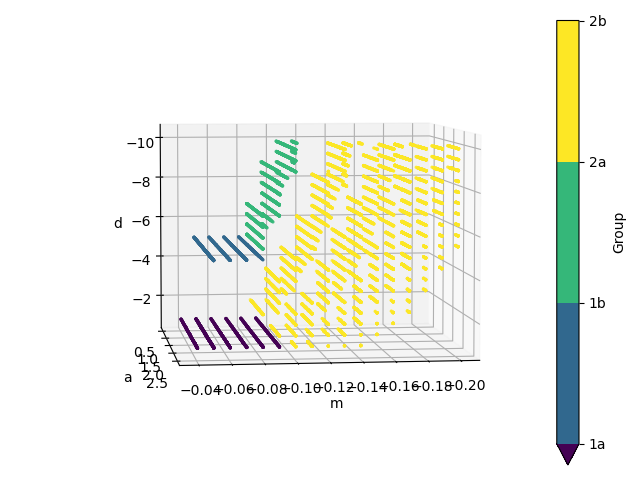

In [15]:
# Plot data
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1, projection="3d")
pl = ax.scatter(avg_results["m"], avg_results["a"], avg_results["d"], c=avg_results["group"], s=2)
ax.set(xlabel="m", ylabel="a", zlabel="d")

# Add color bar
cmap = mpl.cm.viridis
bounds = [1, 2, 3, 4]
norm = mpl.colors.BoundaryNorm(bounds, cmap.N, extend="min")
cbar = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, fraction=0.04, label="Group")
cbar.ax.set_yticklabels(["1a", "1b", "2a", "2b"])

# Set view
ax.view_init(elev=5, azim=83, roll=0)
plt.subplots_adjust(wspace=0.2, hspace=0.2)
plt.gca().invert_zaxis()

plt.tight_layout()

if fig_save_file:
    plt.savefig(fig_save_file)

plt.show()

## Analyze groups

Get the average values of the parameters for each group

In [10]:
avg_results.groupby("group").mean()

,Unnamed: 0,m,d,a,f,l,top_quantile,error,k,af
group,,,,,,,,,,
1.0,17357.642857,-0.062857,-1.000000,1.616667,1.116667,0.000550,0.000000,4.542848e+09,0.052921,1.818147
2.0,17275.955696,-0.061487,-5.000000,1.501582,1.201582,0.000545,0.000000,1.656317e+09,0.051955,1.466692
3.0,13741.894077,-0.090987,-7.824412,1.783144,1.483144,0.000549,0.000000,8.529480e+01,0.072755,1.222601
4.0,6788.837574,-0.140735,-6.008405,2.198054,1.683046,0.000553,0.000757,8.834189e+01,0.107832,1.309635


In [17]:
avg_results.groupby("group").min()

,m,d,a,f,l,top_quantile,error,k,af
group,,,,,,,,,
1.0,-0.09,-1.0,0.6,0.1,0.0001,False,8.145783e+08,0.036804,1.238095
2.0,-0.08,-5.0,0.4,0.1,0.0001,False,2.947248e+08,0.043855,1.130435
3.0,-0.11,-10.0,1.1,0.8,0.0001,False,7.181039e+01,0.065008,1.130435
4.0,-0.20,-10.0,1.5,1.1,0.0001,False,7.542531e+01,0.065008,1.181818


In [18]:
avg_results.groupby("group").max()

,m,d,a,f,l,top_quantile,error,k,af
group,,,,,,,,,
1.0,-0.04,-1.0,2.6,2.1,0.001,False,5.844246e+09,0.072059,6.000
2.0,-0.05,-5.0,2.6,2.3,0.001,False,2.044033e+09,0.065008,4.000
3.0,-0.08,-5.5,2.6,2.3,0.001,False,9.988974e+01,0.086161,1.375
4.0,-0.08,-1.0,2.6,2.2,0.001,True,1.192284e+02,0.149620,1.400


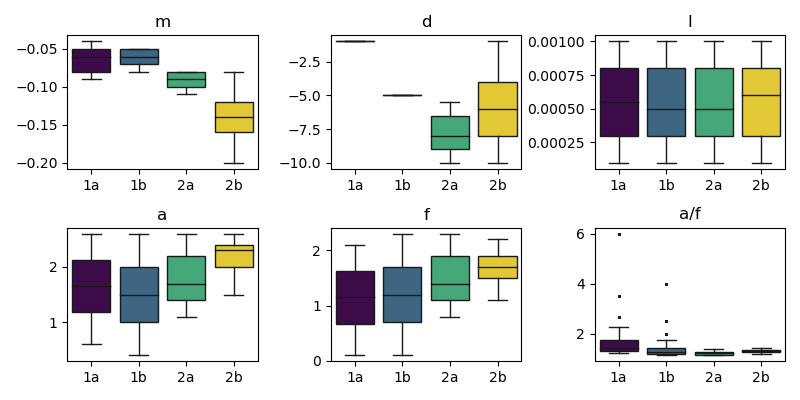

In [20]:
group_colors = ["#440154", "#31688e", "#35b779", "#ffdc17"]
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(8,4))
sns.boxplot(avg_results, x="group", y="m", linewidth=1, palette=group_colors, ax=axes[0][0])
axes[0][0].set(title="m", ylabel="", xlabel="", xticklabels=["1a", "1b", "2a", "2b"])
sns.boxplot(avg_results, x="group", y="d", linewidth=1, palette=group_colors, ax=axes[0][1])
axes[0][1].set(title="d", ylabel="", xlabel="", xticklabels=["1a", "1b", "2a", "2b"])
sns.boxplot(avg_results, x="group", y="l", linewidth=1, palette=group_colors, ax=axes[0][2])
axes[0][2].set(title="l", ylabel="", xlabel="", xticklabels=["1a", "1b", "2a", "2b"])
sns.boxplot(avg_results, x="group", y="a", linewidth=1, palette=group_colors, ax=axes[1][0])
axes[1][0].set(title="a", ylabel="", xlabel="", xticklabels=["1a", "1b", "2a", "2b"])
sns.boxplot(avg_results, x="group", y="f", linewidth=1, palette=group_colors, ax=axes[1][1])
axes[1][1].set(title="f", ylabel="", xlabel="", xticklabels=["1a", "1b", "2a", "2b"])
sns.boxplot(avg_results, x="group", y="af", linewidth=1, fliersize=1.5, flierprops={"marker": "."}, palette=group_colors, ax=axes[1][2])
axes[1][2].set(title="a/f", ylabel="", xlabel="", xticklabels=["1a", "1b", "2a", "2b"])
plt.tight_layout()
plt.show()

In [ ]:
plt.close("all")